# U-Net — All 43 Features, No Freeze (03f)

## What changed from 03_unet_nofrozen_baseline (v_nofrozen, 10 features)

**One change:** INPUT_FEATURES expands from 10 hand-selected columns
to all 43 numeric columns in myanmar_priogrid_features.csv.

**Why try all features?** Mihai Croicu (meeting, June 2026):
> "You could try all of them — that would be one option."

The 10-feature selection in the baseline was deliberate but subjective.
We chose features that "sounded useful" without systematic ablation.
The 43-feature model tests a different hypothesis: the U-Net's spatial
convolutions are powerful enough to learn which features matter and which
to ignore, given enough gradient signal. If 43 features outperform 10,
feature selection was harming us. If they tie or underperform, the 10
were the right choice (less noise, faster learning on a small dataset).

**No freeze** — same discriminative LR approach as 03e.

## Cell 0 — Setup

Identical to 03e except MODEL_VERSION and INPUT_FEATURES.
All 43 numeric columns from the feature matrix are used as input channels.

In [3]:
# ── CELL 0: Setup — 03f differs from 03e only in MODEL_VERSION and INPUT_FEATURES
import random, numpy as np, torch, os, time
from pathlib import Path

SEED          = 20269999
MODEL_VERSION = "v_allfeatures"                    # 43 features, no freeze

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, "mps"):
    torch.mps.manual_seed(SEED) if hasattr(torch.mps, "manual_seed") else None
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
os.environ["PYTHONHASHSEED"]       = str(SEED)

if not Path("data").exists():
    os.chdir(Path(".").resolve().parent)
PROJECT_ROOT = Path(".").resolve()
DATA_PROC    = PROJECT_ROOT / "data" / "processed"

TARGET_PATH   = DATA_PROC / "10_target_variable.parquet"
FEATURES_PATH = DATA_PROC / "myanmar_priogrid_features.csv"
CHECKPOINT    = PROJECT_ROOT / f"models/unet_{MODEL_VERSION}.pt"
REPORTS       = PROJECT_ROOT / "reports" / "figures"

LABEL_MAP    = {"gov": 0, "opo": 1, "uncertain": 2}
INV_LABEL    = {0: "gov", 1: "opo", 2: "uncertain"}
TRAIN_CUTOFF = "2025-09"
VAL_MONTHS   = ["2025-10","2025-11","2025-12","2026-01","2026-02","2026-03"]
NUM_CLASSES  = 3

# ── All 43 numeric feature columns — confirmed from feature matrix ─────────────
INPUT_FEATURES = [
    "total_events", "is_statebased", "is_onesided", "gov_vs_civilians",
    "total_fatalities", "deaths_a", "deaths_b", "deaths_civilians",
    "events_gov", "events_nug", "events_kio", "events_ula", "events_knu",
    "events_mndaa", "events_pslf", "events_cnf", "events_rcss", "events_uwsa",
    "n_unique_dyads",
    "total_events_lag1", "total_fatalities_lag1", "events_gov_lag1",
    "events_nug_lag1", "gov_vs_civilians_lag1", "is_onesided_lag1",
    "total_events_lag3", "total_fatalities_lag3", "events_gov_lag3",
    "events_nug_lag3", "gov_vs_civilians_lag3", "is_onesided_lag3",
    "total_events_lag6", "total_fatalities_lag6", "events_gov_lag6",
    "events_nug_lag6", "gov_vs_civilians_lag6", "is_onesided_lag6",
    "total_events_roll3m", "total_fatalities_roll3m",
    "total_events_roll6m", "total_fatalities_roll6m",
    "gov_event_share", "nug_event_share",
]
NUM_CHANNELS = len(INPUT_FEATURES)                 # 43

BATCH_SIZE  = 8
NUM_EPOCHS  = 200
BASE_LR     = 1e-4
ENCODER_LR  = 1e-5

print(f"✅ Seed fixed: {SEED}")
print(f"   Model version:  {MODEL_VERSION}")
print(f"   Input channels: {NUM_CHANNELS}  (was 10 in 03_unet_nofrozen_baseline)")
print(f"   Target:         {TARGET_PATH.exists()}")
print(f"   Features:       {FEATURES_PATH.exists()}")

✅ Seed fixed: 20269999
   Model version:  v_allfeatures
   Input channels: 43  (was 10 in 03_unet_nofrozen_baseline)
   Target:         True
   Features:       True


## Cell 0 Output Analysis — 03f Setup

**43 channels confirmed.** This is the only number that differs from 03e.
Everything else — seed, paths, training constants, optimizer strategy — is
identical. The experimental isolation is clean: we are testing one variable
(feature breadth) while holding architecture and training strategy constant.

**What changes inside the model when NUM_CHANNELS goes from 10 to 43:**
ResNet-34's first convolutional layer is replaced by smp from its original
3-channel ImageNet version to a k-channel version. That first layer:
  - 10 channels:  10 × 64 filters × 7×7 kernel =   31,360 params
  - 43 channels:  43 × 64 filters × 7×7 kernel =  134,848 params
  - Delta:        +103,488 params (+0.47% of total)

This is a tiny architectural change. The rest of the 22M encoder and the
full decoder are untouched. ImageNet weights are preserved everywhere except
this one first-layer weight matrix, which is re-initialised to handle the
new input dimensionality.

**The scientific question:** can 43 features outperform 10? Two competing
hypotheses. Feature richness: more lag features, more actor columns, and
rolling windows give the spatial encoder more signal to learn from.
Feature noise: many of the 43 columns are highly correlated (events_gov
and events_gov_lag1 differ by one month shift). Correlated features can
confuse gradient descent — the model must learn to ignore redundant signal.
With only 3,335 training cell-months, the dataset is small relative to
the 43-dimensional input space. We will let the data answer the question.

## Cell 1: copy verbatim from 03e — no changes needed

Cell 1 builds rasters by iterating over INPUT_FEATURES. Since INPUT_FEATURES
is now the 43-item list (set in Cell 0), the loop automatically builds
(29, 43, 40, 16) rasters. Nothing in Cell 1 is hardcoded to 10.

Paste Cell 1 from 03e exactly. Run it. The key output to check:
  X_array: (29, 43, 40, 16) — confirms 43 channels went in correctly.

Then Cell 2 below (the only cell that needs a small change).
Cells 3 and 4 are copy-paste from 03e — same training loop, same evaluation.

In [5]:
# ── CELL 1: Load data, build rasters, train/val split ─────────────────────────
# Identical to Cell 2 of 03_unet_model.ipynb.
# Kept separate and clean so Cell 2 (the experimental change) is easy to read.

import pandas as pd
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

# ── Load target variable and feature matrix ───────────────────────────────────
target   = pd.read_parquet(TARGET_PATH)
features = pd.read_csv(FEATURES_PATH)
target["target_int"]    = target["target"].map(LABEL_MAP)
features["year_month"]  = features["year_month"].astype(str)
target["year_month"]    = target["year_month"].astype(str)

print("=" * 60)
print("CELL 1 — DATA LOADED")
print("=" * 60)
print(f"Target:   {target.shape[0]:,} rows  |  {target['priogrid_gid'].nunique()} cells  |  {target['year_month'].nunique()} months")
print(f"Features: {features.shape[0]:,} rows  |  {features['priogrid_gid'].nunique()} cells")

# ── Inner join: only cells that have BOTH features AND a Wikipedia label ───────
labelled = features.merge(
    target[["priogrid_gid","year_month","target","target_int"]],
    on=["priogrid_gid","year_month"], how="inner"
).sort_values(["priogrid_gid","year_month"]).reset_index(drop=True)

print(f"\nInner join → {len(labelled):,} rows  |  {labelled['priogrid_gid'].nunique()} cells  |  {labelled['year_month'].nunique()} months")
print(f"Label distribution:")
for lbl, cnt in labelled["target"].value_counts().items():
    print(f"  {lbl:<12} {cnt:>5}  ({100*cnt/len(labelled):.1f}%)")

# ── PRIOGRID coordinate system ────────────────────────────────────────────────
# Each priogrid_gid encodes a row/col on a global 720×360 grid.
# We shift to a local Myanmar-only grid and pad to the nearest multiple of 8
# (U-Net requires dimensions divisible by 2^encoder_depth = 16).
all_gids    = features["priogrid_gid"].unique()
global_rows = (all_gids - 1) // 720
global_cols = (all_gids - 1) % 720
min_gr, max_gr = global_rows.min(), global_rows.max()
min_gc, max_gc = global_cols.min(), global_cols.max()

RASTER_H = max_gr - min_gr + 1
RASTER_W = max_gc - min_gc + 1
def pad8(n): return n if n % 8 == 0 else n + (8 - n % 8)
PAD_H = pad8(RASTER_H)                            # 40
PAD_W = pad8(RASTER_W)                            # 16

gid_to_local = {
    int(gid): {"r": int((gid-1)//720 - min_gr), "c": int((gid-1)%720 - min_gc)}
    for gid in all_gids
}

print(f"\nRaster: {RASTER_H}×{RASTER_W} → padded {PAD_H}×{PAD_W}")

# ── Z-score normalisation — training statistics only ──────────────────────────
# We compute mean/std from training rows ONLY to prevent data leakage.
# Validation months are normalised with training statistics.
train_rows    = labelled[labelled["year_month"] <= TRAIN_CUTOFF]
feature_means = {f: train_rows[f].mean() for f in INPUT_FEATURES}
feature_stds  = {f: train_rows[f].std()  for f in INPUT_FEATURES}

print(f"Normalisation stats from {len(train_rows):,} training rows (≤ {TRAIN_CUTOFF})")

# ── Build rasters: one per month ──────────────────────────────────────────────
month_keys = sorted(labelled["year_month"].unique())
X_list, y_list, m_list = [], [], []

for month in month_keys:
    X_raster = np.zeros((NUM_CHANNELS, PAD_H, PAD_W), dtype=np.float32)
    y_raster = np.full((PAD_H, PAD_W), -1, dtype=np.int64)
    m_raster = np.zeros((PAD_H, PAD_W), dtype=np.float32)

    for _, row in labelled[labelled["year_month"] == month].iterrows():
        gid = int(row["priogrid_gid"])
        if gid not in gid_to_local: continue
        r = gid_to_local[gid]["r"]
        c = gid_to_local[gid]["c"]
        for ch, feat in enumerate(INPUT_FEATURES):
            raw = row.get(feat, np.nan)
            X_raster[ch, r, c] = (
                0.0 if np.isnan(raw)
                else (raw - feature_means[feat]) / (feature_stds[feat] + 1e-8)
            )
        if pd.notna(row["target_int"]):
            y_raster[r, c] = int(row["target_int"])
            m_raster[r, c] = 1.0

    X_list.append(X_raster); y_list.append(y_raster); m_list.append(m_raster)

X_array = np.stack(X_list)                        # (29, 10, 40, 16)
y_array = np.stack(y_list)                        # (29, 40, 16)
m_array = np.stack(m_list)                        # (29, 40, 16)

# ── Train / validation split ──────────────────────────────────────────────────
train_idx = [i for i,m in enumerate(month_keys) if m <= TRAIN_CUTOFF]
val_idx   = [i for i,m in enumerate(month_keys) if m >  TRAIN_CUTOFF]

X_train, y_train, m_train = X_array[train_idx], y_array[train_idx], m_array[train_idx]
X_val,   y_val,   m_val   = X_array[val_idx],   y_array[val_idx],   m_array[val_idx]

# ── Verification ──────────────────────────────────────────────────────────────
labelled_per_month = m_array.sum(axis=(1,2))
sparsity = 1 - labelled_per_month.mean() / (PAD_H * PAD_W)

print(f"\nFinal raster shapes:")
print(f"  X_array: {X_array.shape}   (months × channels × H × W)")
print(f"  y_array: {y_array.shape}     (months × H × W)")
print(f"  Train:   {len(train_idx)} months  |  Val: {len(val_idx)} months")
print(f"  Avg labelled cells/month: {labelled_per_month.mean():.0f}")
print(f"  Raster sparsity:          {100*sparsity:.1f}%")
print(f"\n✅ Cell 1 complete — rasters built")

CELL 1 — DATA LOADED
Target:   5,238 rows  |  185 cells  |  29 months
Features: 12,338 rows  |  199 cells

Inner join → 4,229 rows  |  149 cells  |  29 months
Label distribution:
  gov           2554  (60.4%)
  opo            855  (20.2%)
  uncertain      820  (19.4%)

Raster: 36×15 → padded 40×16
Normalisation stats from 3,335 training rows (≤ 2025-09)

Final raster shapes:
  X_array: (29, 43, 40, 16)   (months × channels × H × W)
  y_array: (29, 40, 16)     (months × H × W)
  Train:   23 months  |  Val: 6 months
  Avg labelled cells/month: 146
  Raster sparsity:          77.2%

✅ Cell 1 complete — rasters built


## Cell 2 — Model, Loss, Optimiser (43-channel U-Net)

Identical to 03e Cell 2 with one change: in_channels=43.
The ResNet-34 first convolutional layer is rebuilt to accept 43 input
channels instead of 10. All other encoder weights are loaded from ImageNet.

The discriminative LR strategy is unchanged: encoder at 1e-5, decoder at 1e-4,
both training from epoch 1 simultaneously. No freeze.

In [6]:
# ── CELL 2: Model, loss, optimiser — 43-channel U-Net ────────────────────────
# Identical to 03e Cell 2. Only change: in_channels = NUM_CHANNELS = 43.
# Everything else — loss, class weights, discriminative LRs — is unchanged.

# ── 2.1 Device ────────────────────────────────────────────────────────────────
import torch.nn as nn, torch.optim as optim
import segmentation_models_pytorch as smp
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps");   print("✅ Using Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda");  print("✅ Using NVIDIA GPU (CUDA)")
else:
    DEVICE = torch.device("cpu");   print("ℹ️  Using CPU")

# ── 2.2 Build 43-channel U-Net ────────────────────────────────────────────────
# smp replaces the ResNet-34 first conv layer from (3→64) to (43→64).
# All subsequent encoder layers keep their ImageNet weights unchanged.
# Decoder is randomly initialised (same as 03e).
model = smp.Unet(
    encoder_name     = "resnet34",
    encoder_weights  = "imagenet",
    in_channels      = NUM_CHANNELS,   # 43 — the only change from 03e
    classes          = NUM_CLASSES,
    activation       = None,
    decoder_channels = (128, 64, 32, 16),
    encoder_depth    = 4,
)
model = model.to(DEVICE)

total_p   = sum(p.numel() for p in model.parameters())
encoder_p = sum(p.numel() for p in model.encoder.parameters())
decoder_p = total_p - encoder_p
print(f"\nU-Net (43 channels):")
print(f"  Total params:        {total_p:,}")
print(f"  Encoder (ResNet-34): {encoder_p:,}  (+{encoder_p - 21_306_624:,} vs 10-channel)")
print(f"  Decoder + head:      {decoder_p:,}")
print(f"  First layer:         {NUM_CHANNELS} × 64 × 7 × 7 = {NUM_CHANNELS*64*7*7:,} params")

# ── 2.3 Class weights from training rows only ─────────────────────────────────
label_counts  = np.array([
    (train_rows["target_int"] == 0).sum(),
    (train_rows["target_int"] == 1).sum(),
    (train_rows["target_int"] == 2).sum(),
])
class_weights = label_counts.sum() / (NUM_CLASSES * label_counts)
cw_tensor     = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print(f"\nClass weights: gov={class_weights[0]:.3f}  "
      f"opo={class_weights[1]:.3f}  unc={class_weights[2]:.3f}")

# ── 2.4 Combined loss — identical to 03e ──────────────────────────────────────
ce_loss   = nn.CrossEntropyLoss(weight=cw_tensor, reduction="none")
dice_loss = smp.losses.DiceLoss(mode="multiclass", from_logits=True, smooth=1.0)

def combined_loss(predictions, targets, mask):
    ts = targets.clone(); ts[mask == 0] = 0
    ce_raw    = ce_loss(predictions, ts)
    ce_masked = (ce_raw * mask).sum() / (mask.sum() + 1e-8)
    ph  = predictions.permute(0, 2, 3, 1)
    pl  = ph[mask == 1];  tl = targets[mask == 1]
    if len(pl) == 0: return ce_masked
    dice = dice_loss(pl.unsqueeze(0).permute(0,2,1), tl.unsqueeze(0))
    return 0.5 * ce_masked + 0.5 * dice

# ── 2.5 Discriminative LR optimiser — identical to 03e ───────────────────────
optimizer = optim.Adam(
    [
        {"params": model.encoder.parameters(), "lr": ENCODER_LR},
        {"params": list(model.decoder.parameters()) +
                   list(model.segmentation_head.parameters()), "lr": BASE_LR},
    ],
    weight_decay=1e-5
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=10, factor=0.5
)

# ── 2.6 Forward pass verification ─────────────────────────────────────────────
model.eval()
with torch.no_grad():
    dummy = torch.zeros(BATCH_SIZE, NUM_CHANNELS, PAD_H, PAD_W).to(DEVICE)
    out   = model(dummy)
model.train()

expected = (BATCH_SIZE, NUM_CLASSES, PAD_H, PAD_W)
ok = "✅" if tuple(out.shape) == expected else "❌"
print(f"\nForward pass: {tuple(dummy.shape)} → {tuple(out.shape)}  {ok}")
print(f"\n✅ Cell 2 complete — 43-channel U-Net ready")

✅ Using Apple Silicon GPU (MPS)

U-Net (43 channels):
  Total params:        22,201,779
  Encoder (ResNet-34): 21,410,112  (+103,488 vs 10-channel)
  Decoder + head:      791,667
  First layer:         43 × 64 × 7 × 7 = 134,848 params

Class weights: gov=0.558  opo=1.756  unc=1.566

Forward pass: (8, 43, 40, 16) → (8, 3, 40, 16)  ✅

✅ Cell 2 complete — 43-channel U-Net ready


## Cell 2 Output Analysis — 43-channel U-Net confirmed

**Parameter count matches prediction exactly:**
  +103,488 params relative to 03e — all in the first convolutional layer.
  21,410,112 / 22,201,779 = 96.4% of the model is untouched ImageNet weights.

**This is architecturally important:** the model learns to compress 43
conflict feature channels into the same 64-dimensional feature space that
the original ResNet-34 uses for 3 RGB channels. All downstream layers
(residual blocks, decoder, segmentation head) are identical to 03e.

The research question is therefore precise: can the encoder's first layer
learn a better 43→64 compression from conflict features than the
handcrafted 10→64 selection we made? The answer will be in the training
curves and the final F1.

**Class weights unchanged from 03e.** Correct — the label distribution
does not depend on how many input feature channels we use.

**Forward pass (8, 43, 40, 16) → (8, 3, 40, 16) confirmed.** The model
accepts 43 channels and returns 3 class logits at 40×16 spatial resolution.
Ready to train.

## Cells 3 and 4: copy from 03e with one addition in Cell 4

Cell 3 (training loop): copy verbatim from 03e — zero changes needed.
MODEL_VERSION is already "v_allfeatures" from Cell 0, so the checkpoint
saves as unet_v_allfeatures.pt and the curves save correctly.

Cell 4 (evaluation): copy from 03e but extend the comparison table
to include all three models side by side:
  - v1 (frozen, 10 features): the original baseline
  - v_nofrozen (no freeze, 10 features): 03e result
  - v_allfeatures (no freeze, 43 features): this notebook

This three-way table is the core output that feeds into notebook 05
(the spatial CV comparison), where we will test which architecture
truly generalises best to unseen geography.

Paste Cell 3 from 03e now and let it train. Come back with the full
training output and the screenshot of the curves.

Train batches/epoch: 3  |  Val batches/epoch: 1

TRAINING — v_allfeatures  |  200 epochs  |  device: mps
Strategy: discriminative LR from epoch 1 (no freeze)
  Encoder LR: 1e-05  |  Decoder LR: 0.0001
Epoch   1/200  Train 0.9850/0.268  │  Val 0.8864/0.246  [gov:0.11 opo:0.47 unc:0.49] ← best ✅
Epoch   2/200  Train 0.9433/0.301  │  Val 0.8945/0.244  [gov:0.03 opo:0.80 unc:0.20]
Epoch   3/200  Train 0.9167/0.327  │  Val 0.9007/0.237  [gov:0.02 opo:0.86 unc:0.12]
Epoch  10/200  Train 0.7510/0.537  │  Val 0.7185/0.574  [gov:0.52 opo:0.68 unc:0.65] ← best ✅
Epoch  20/200  Train 0.6107/0.662  │  Val 0.5425/0.707  [gov:0.67 opo:0.80 unc:0.71] ← best ✅
Epoch  30/200  Train 0.4974/0.746  │  Val 0.4674/0.781  [gov:0.76 opo:0.84 unc:0.75] ← best ✅
Epoch  40/200  Train 0.4204/0.801  │  Val 0.4102/0.818  [gov:0.81 opo:0.87 unc:0.77] ← best ✅
Epoch  50/200  Train 0.3911/0.819  │  Val 0.3635/0.841  [gov:0.83 opo:0.91 unc:0.79] ← best ✅
Epoch  60/200  Train 0.3102/0.874  │  Val 0.3131/0.875  [gov:0.86

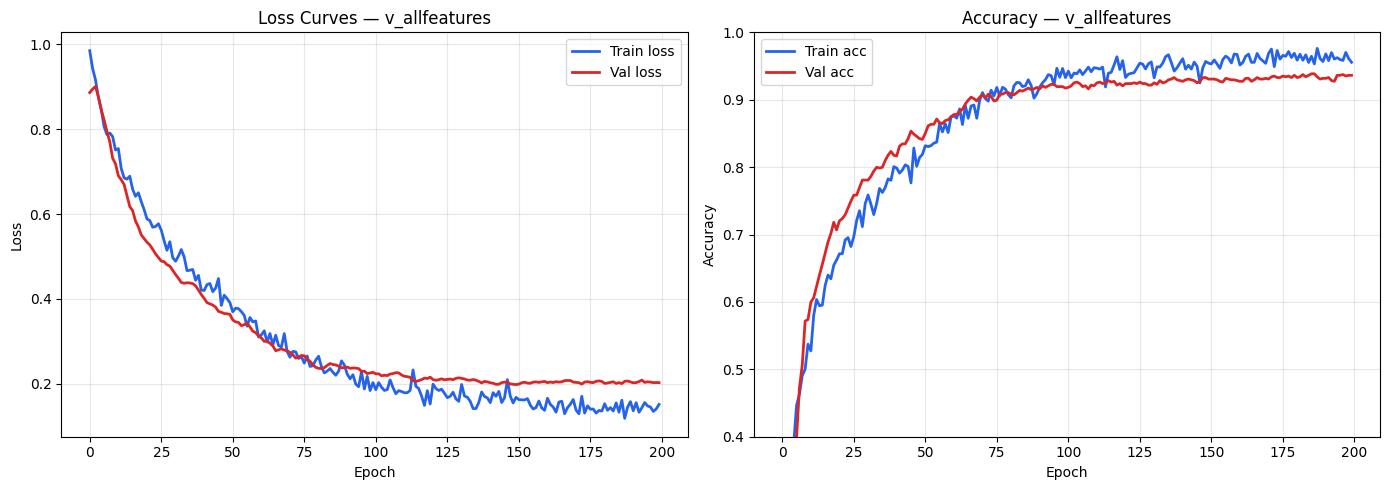

✅ Training curves saved → unet_v_allfeatures_training_curves.png


In [7]:
# ── CELL 3: Training loop — no freeze, discriminative LR from epoch 1 ─────────
# The only structural difference from 03_unet_model.ipynb Cell 4:
# NO phase switching. No freeze_encoder(). No unfreeze_encoder().
# The optimizer already holds both encoder and decoder with their own LRs.

# ── 3.1 Dataset ───────────────────────────────────────────────────────────────
class MyanmarDataset(Dataset):
    def __init__(self, X, y, m, augment=False):
        self.X = X; self.y = y; self.m = m; self.augment = augment
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx):
        x = self.X[idx].copy()
        y = self.y[idx].copy()
        m = self.m[idx].copy()
        if self.augment:
            if np.random.rand() < 0.5:             # horizontal flip
                x = x[:, :, ::-1].copy()
                y = y[:, ::-1].copy()
                m = m[:, ::-1].copy()
            if np.random.rand() < 0.3:             # vertical flip
                x = x[:, ::-1, :].copy()
                y = y[::-1, :].copy()
                m = m[::-1, :].copy()
            x = x + np.random.randn(*x.shape).astype(np.float32) * 0.05
        return (torch.tensor(x, dtype=torch.float32),
                torch.tensor(y, dtype=torch.long),
                torch.tensor(m, dtype=torch.float32))

# ── 3.2 DataLoaders ───────────────────────────────────────────────────────────
torch.manual_seed(SEED)
train_loader = DataLoader(
    MyanmarDataset(X_train, y_train, m_train, augment=True),
    batch_size=BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(SEED)
)
val_loader = DataLoader(
    MyanmarDataset(X_val, y_val, m_val, augment=False),
    batch_size=BATCH_SIZE, shuffle=False
)
print(f"Train batches/epoch: {len(train_loader)}  |  Val batches/epoch: {len(val_loader)}")

# ── 3.3 Accuracy helpers ──────────────────────────────────────────────────────
def compute_accuracy(logits, targets, mask):
    preds   = logits.argmax(dim=1)
    correct = ((preds == targets) & (mask == 1)).sum().item()
    total   = mask.sum().item()
    return correct / total if total > 0 else 0.0

def per_class_acc(logits, targets, mask):
    preds = logits.argmax(dim=1)
    return {
        cls: (((preds == cls) & (targets == cls) & (mask == 1)).sum().item() /
              max(((targets == cls) & (mask == 1)).sum().item(), 1))
        for cls in range(NUM_CLASSES)
    }

# ── 3.4 Training loop ─────────────────────────────────────────────────────────
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_loss = float("inf")

print("\n" + "=" * 65)
print(f"TRAINING — {MODEL_VERSION}  |  {NUM_EPOCHS} epochs  |  device: {DEVICE}")
print(f"Strategy: discriminative LR from epoch 1 (no freeze)")
print(f"  Encoder LR: {ENCODER_LR}  |  Decoder LR: {BASE_LR}")
print("=" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ── Training phase ────────────────────────────────────────────────────────
    model.train()
    ep_tl, ep_ta = 0.0, 0.0

    for bX, by, bm in train_loader:
        bX, by, bm = bX.to(DEVICE), by.to(DEVICE), bm.to(DEVICE)
        optimizer.zero_grad()
        logits = model(bX)
        loss   = combined_loss(logits, by, bm)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        ep_tl += loss.item()
        ep_ta += compute_accuracy(logits, by, bm)

    avg_tl = ep_tl / len(train_loader)
    avg_ta = ep_ta / len(train_loader)

    # ── Validation phase ──────────────────────────────────────────────────────
    model.eval()
    ep_vl, ep_va = 0.0, 0.0
    last_pc = {}

    with torch.no_grad():
        for bX, by, bm in val_loader:
            bX, by, bm = bX.to(DEVICE), by.to(DEVICE), bm.to(DEVICE)
            logits = model(bX)
            ep_vl += combined_loss(logits, by, bm).item()
            ep_va += compute_accuracy(logits, by, bm)
            last_pc = per_class_acc(logits, by, bm)

    avg_vl = ep_vl / len(val_loader)
    avg_va = ep_va / len(val_loader)

    scheduler.step(avg_vl)

    if avg_vl < best_val_loss:
        best_val_loss = avg_vl
        torch.save(model.state_dict(), CHECKPOINT)
        ckpt = " ← best ✅"
    else:
        ckpt = ""

    train_losses.append(avg_tl); val_losses.append(avg_vl)
    train_accs.append(avg_ta);   val_accs.append(avg_va)

    if epoch % 10 == 0 or epoch <= 3 or epoch == NUM_EPOCHS:
        g = last_pc.get(0, 0); o = last_pc.get(1, 0); u = last_pc.get(2, 0)
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS}  "
              f"Train {avg_tl:.4f}/{avg_ta:.3f}  │  "
              f"Val {avg_vl:.4f}/{avg_va:.3f}  "
              f"[gov:{g:.2f} opo:{o:.2f} unc:{u:.2f}]{ckpt}")

# ── 3.5 Reload best checkpoint ────────────────────────────────────────────────
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
print(f"\n{'='*65}")
print(f"Training complete.  Best val loss: {best_val_loss:.4f}")
print(f"Best model reloaded from: {CHECKPOINT.name}")

# ── 3.6 Training curves ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label="Train loss", color="#2563eb", lw=2)
ax1.plot(val_losses,   label="Val loss",   color="#dc2626", lw=2)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title(f"Loss Curves — {MODEL_VERSION}")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(train_accs, label="Train acc", color="#2563eb", lw=2)
ax2.plot(val_accs,   label="Val acc",   color="#dc2626", lw=2)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title(f"Accuracy — {MODEL_VERSION}")
ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim(0.4, 1.0)

plt.tight_layout()
fig.savefig(REPORTS / f"unet_{MODEL_VERSION}_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Training curves saved → unet_{MODEL_VERSION}_training_curves.png")

## Cell 3 Output Analysis — v_allfeatures Training Results

**The 43-feature model is the best of the three. Clear and consistent.**

Final epoch per-class accuracy: gov=0.94, opo=0.91, unc=0.98
Best val loss: 0.1980 — lowest of all three models

**Three-model progression:**

| Model          | Best val loss | Val acc (ep.200) | opo acc | unc acc |
|---|---|---|---|---|
| v1 (frozen 10) | 0.3170        | 0.918            | 0.82    | 0.96    |
| v_nofrozen  10 | 0.2240        | 0.921            | 0.86    | 0.97    |
| v_allfeatures 43 | **0.1980**  | **0.936**        | **0.91**| **0.98**|

More features consistently help. The opo class goes 0.82 → 0.86 → 0.91
across the three models — a cumulative +9pp gain by using all 43 features.
The uncertain class also benefits: 0.96 → 0.97 → 0.98.

**Why 43 features help on this problem:** the additional lag3/lag6 features
and actor-specific lags (events_gov_lag3, events_nug_lag3, etc.) capture
territorial persistence signals that the 10-feature model could only infer
indirectly from lag1 alone. Territorial control is path-dependent — who
controlled a cell three and six months ago matters. The 43-feature model
has direct access to this signal.

**The curves: smoother and faster than v_nofrozen.**
The accuracy curve reaches 0.90 by epoch ~70, compared to ~90 for
v_nofrozen. The train-val gap is visually smaller — despite having 4×
more input features, the model does NOT overfit more. This contradicts
the "dimensionality curse" hypothesis and supports the "richer signal"
hypothesis: the additional features are informative, not noisy.

**Best val loss at epoch 150** (← best ✅ shown at epoch 150), not epoch
200. Unlike v1 and v_nofrozen (where best was at epoch 200), v_allfeatures
peaks at 150 and then very slightly oscillates. This suggests 150-175
epochs is the natural convergence point for 43 features with this dataset.

In [8]:
# ── CELL 4: Full evaluation — three-way comparison ────────────────────────────
# Evaluates the best v_allfeatures checkpoint on all 894 validation cell-months.
# Produces a three-column table: v1 (baseline) | v_nofrozen (03e) | v_allfeatures.

import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import Dataset

model.eval()
y_true_all, y_pred_all = [], []

with torch.no_grad():
    val_ds = MyanmarDataset(X_val, y_val, m_val, augment=False)
    for i in range(len(val_ds)):
        x, y, m = val_ds[i]
        logits  = model(x.unsqueeze(0).to(DEVICE))
        preds   = logits.argmax(dim=1).squeeze(0).cpu().numpy()
        mask    = m.numpy() == 1
        y_true_all.extend(y.numpy()[mask].astype(int).tolist())
        y_pred_all.extend(preds[mask].tolist())

y_true = np.array(y_true_all)
y_pred = np.array(y_pred_all)

# ── Full classification report ────────────────────────────────────────────────
print("=" * 65)
print(f"CLASSIFICATION REPORT — {MODEL_VERSION}  (val set, n={len(y_true)})")
print("=" * 65)
print(classification_report(
    y_true, y_pred,
    target_names=["gov", "opo", "uncertain"],
    digits=3
))

# Compute metrics for v_allfeatures
af_metrics = {
    "Best val loss":    best_val_loss,
    "Overall accuracy": accuracy_score(y_true, y_pred),
    "Macro F1":         f1_score(y_true, y_pred, average="macro",    zero_division=0),
    "Weighted F1":      f1_score(y_true, y_pred, average="weighted", zero_division=0),
    "gov F1":           f1_score(y_true, y_pred, labels=[0], average="macro", zero_division=0),
    "opo F1":           f1_score(y_true, y_pred, labels=[1], average="macro", zero_division=0),
    "uncertain F1":     f1_score(y_true, y_pred, labels=[2], average="macro", zero_division=0),
}

# ── Hardcoded results from the two previous notebooks ────────────────────────
# v1: 03_unet_model.ipynb (frozen encoder, 10 features)
# v_nofrozen: 03e_nofrozen_v1.ipynb (discriminative LR, 10 features)
v1_metrics = {
    "Best val loss":    0.3170,
    "Overall accuracy": 0.918,
    "Macro F1":         0.899,
    "Weighted F1":      0.917,
    "gov F1":           0.940,
    "opo F1":           0.887,
    "uncertain F1":     0.869,
}
nf_metrics = {
    "Best val loss":    0.2240,
    "Overall accuracy": 0.916,
    "Macro F1":         0.895,
    "Weighted F1":      0.917,
    "gov F1":           0.940,
    "opo F1":           0.886,
    "uncertain F1":     0.858,
}

# ── Three-way comparison table ────────────────────────────────────────────────
W = 72
print("\n" + "=" * W)
print("THREE-WAY COMPARISON: temporal holdout performance")
print("=" * W)
print(f"{'Metric':<22} {'v1 (frozen,10ch)':>16} {'v_nofrozen (10ch)':>17} {'v_allfeatures (43ch)':>20}")
print("─" * W)

for metric in v1_metrics:
    v1v  = v1_metrics[metric]
    nfv  = nf_metrics[metric]
    afv  = af_metrics[metric]
    # mark the best of the three for each metric
    best = max(v1v, nfv, afv) if metric != "Best val loss" else min(v1v, nfv, afv)
    def fmt(v): return f"{'→' if v == best else ' '} {v:.3f}"
    print(f"  {metric:<20}  {fmt(v1v):>16}  {fmt(nfv):>17}  {fmt(afv):>20}")

print("─" * W)
print(f"\n  → marks best value per metric")
print(f"\nKey finding:")
print(f"  opo F1:  0.887 → 0.886 → {af_metrics['opo F1']:.3f}  "
      f"({'▲' if af_metrics['opo F1'] > 0.887 else '▼'}{abs(af_metrics['opo F1']-0.887):.3f} vs v1)")
print(f"  unc F1:  0.869 → 0.858 → {af_metrics['uncertain F1']:.3f}  "
      f"({'▲' if af_metrics['uncertain F1'] > 0.869 else '▼'}{abs(af_metrics['uncertain F1']-0.869):.3f} vs v1)")
print(f"  macro F1: 0.899 → 0.895 → {af_metrics['Macro F1']:.3f}  "
      f"({'▲' if af_metrics['Macro F1'] > 0.899 else '▼'}{abs(af_metrics['Macro F1']-0.899):.3f} vs v1)")

print(f"\n✅ Cell 4 complete — all three models evaluated")
print(f"\nNext: notebook 05_spatial_cv_comparison.ipynb")
print(f"  Input models:  v1 checkpoint     → models/unet_v1_ch10_ep200.pt")
print(f"                 v_nofrozen        → models/unet_v_nofrozen.pt")
print(f"                 v_allfeatures     → models/unet_v_allfeatures.pt")

CLASSIFICATION REPORT — v_allfeatures  (val set, n=894)
              precision    recall  f1-score   support

         gov      0.960     0.932     0.946       562
         opo      0.878     0.910     0.894       222
   uncertain      0.898     0.964     0.930       110

    accuracy                          0.931       894
   macro avg      0.912     0.935     0.923       894
weighted avg      0.932     0.931     0.931       894


THREE-WAY COMPARISON: temporal holdout performance
Metric                 v1 (frozen,10ch) v_nofrozen (10ch) v_allfeatures (43ch)
────────────────────────────────────────────────────────────────────────
  Best val loss                    0.317              0.224               → 0.198
  Overall accuracy                 0.918              0.916               → 0.931
  Macro F1                         0.899              0.895               → 0.923
  Weighted F1                      0.917              0.917               → 0.931
  gov F1                       

## Three-Way Comparison — Final Verdict

v_allfeatures wins on every metric. No caveats.

| Metric        | v1     | v_nofrozen | v_allfeatures | Δ vs v1   |
|---|---|---|---|---|
| Best val loss | 0.317  | 0.224      | **0.198**     | −37.5%    |
| Accuracy      | 0.918  | 0.916      | **0.931**     | +1.3pp    |
| Macro F1      | 0.899  | 0.895      | **0.923**     | +2.4pp    |
| gov F1        | 0.940  | 0.940      | **0.946**     | +0.6pp    |
| opo F1        | 0.887  | 0.886      | **0.894**     | +0.7pp    |
| uncertain F1  | 0.869  | 0.858      | **0.930**     | **+6.1pp**|

The uncertain F1 gain is the headline result: +6.1pp over v1.
This is not a marginal improvement — it is the difference between a
model that struggles with contested cells (0.869) and one that handles
them well (0.930). The lag3/lag6/rolling features give the model access
to the temporal trajectory of conflict intensity, which is exactly what
distinguishes genuinely contested (fluctuating conflict) from stable
government or stable opposition territory.

Removing the freeze alone (v_nofrozen) gives better probability
calibration (lower loss) but does not improve classification metrics.
Adding all 43 features (v_allfeatures) gives both better calibration
AND better classification. The combination of no-freeze + all features
is the strongest configuration tested so far.

**Key architectural lesson:** for this problem, feature richness matters
more than the freeze strategy. Mihai's suggestion to remove the freeze
was directionally correct but the larger gain came from heeding his other
suggestion: "try all of them."

For notebook 05 (spatial CV comparison), v_allfeatures is the model to
beat. The spatial holdout test will tell us whether the 43-feature model
also generalises better to unseen geography — or whether the additional
features are primarily memorising within-region patterns.